<a href="https://colab.research.google.com/github/zulaikha210072/MoveAndLearn_HCI_Project/blob/main/Week2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the dataset (replace with your file path or use a sample dataset)
df = pd.read_csv("https://ourworldindata.org/grapher/mean-years-of-schooling-long-run.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

print(f"Loaded dataset with {df.shape[0]:,} rows and {df.shape[1]} columns.")

Loaded dataset with 3,699 rows and 4 columns.


In [2]:
# Preview the data
df.head()

,entity,code,year,mf_youth_and_adults__15_64_years__average_years_of_education
0,Afghanistan,AFG,1870,0.01
1,Afghanistan,AFG,1875,0.01
2,Afghanistan,AFG,1880,0.01
3,Afghanistan,AFG,1885,0.01
4,Afghanistan,AFG,1890,0.01


In [3]:
# List columns and data types
print("Columns:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Columns: ['entity', 'code', 'year', 'mf_youth_and_adults__15_64_years__average_years_of_education']

Data types:
entity                                                           object
code                                                             object
year                                                              int64
mf_youth_and_adults__15_64_years__average_years_of_education    float64
dtype: object


In [4]:
# Summary statistics for numeric columns
df.describe()

,year,mf_youth_and_adults__15_64_years__average_years_of_education
count,3699.000000,3699.000000
mean,1946.411192,3.813287
std,45.410017,3.640816
min,1870.000000,0.000000
25%,1905.000000,0.540000
50%,1945.000000,2.760000
75%,1985.000000,6.370000
max,2020.000000,13.740000


In [5]:
# Count unique countries
print("Number of unique countries:", df['entity'].nunique())

# Count years covered
print("Years covered:", df['year'].min(), "to", df['year'].max())

Number of unique countries: 153
Years covered: 1870 to 2020


In [6]:
print("Number of unique countries:", df['entity'].nunique())

# Count years covered
print("Years covered:", df['year'].min(), "to", df['year'].min())

Number of unique countries: 153
Years covered: 1870 to 1870


In [7]:
# Check for missing values
df.isnull().sum().sort_values(ascending=False).head(10)

,0
code,157
entity,0
year,0
mf_youth_and_adults__15_64_years__average_years_of_education,0


In [10]:
# Drop rows with missing mean years of schooling

df_clean = df.dropna(subset=['mf_youth_and_adults__15_64_years__average_years_of_education'])

# Rename columns for clarity
df_clean = df_clean.rename(columns={
    'entity': 'Country',
    'mf_youth_and_adults__15_64_years__average_years_of_education': 'mean_years_schooling'
})

df_clean.head()

,Country,code,year,mean_years_schooling
0,Afghanistan,AFG,1870,0.01
1,Afghanistan,AFG,1875,0.01
2,Afghanistan,AFG,1880,0.01
3,Afghanistan,AFG,1885,0.01
4,Afghanistan,AFG,1890,0.01


In [13]:
top_schooling = df_clean[df_clean['year'] == 2020].sort_values('mean_years_schooling', ascending=False)
top_schooling[['Country', 'mean_years_schooling']].head()

,Country,mean_years_schooling
1693,Ireland,13.74
3035,South Korea,13.68
1538,Iceland,13.53
3510,United States,13.32
2940,Slovakia,13.14


In [14]:
# Group by country and calculate mean years of schooling over all years
country_avg = df_clean.groupby('Country')['mean_years_schooling'].mean().sort_values(ascending=False)
country_avg.head()

,mean_years_schooling
Country,
Slovakia,13.085
Singapore,12.800
Lithuania,12.470
Estonia,12.310
Israel,12.040


**My Task to answer to some Question! **

In [16]:
#What is the average mean years of schooling for the top 10 countries in 2018?
# Filter for year 2018
data_2018 = df_clean[df_clean['year'] == 2018]

# Get top 10 countries by schooling
top10_2018 = data_2018.sort_values('mean_years_schooling', ascending=False).head(10)

# Calculate their average
avg_top10_2018 = top10_2018['mean_years_schooling'].mean()

print("Top 10 countries in 2018:")
print(top10_2018[['Country','mean_years_schooling']])
print("\nAverage schooling of top 10 in 2018:", round(avg_top10_2018,2))

Top 10 countries in 2018:
Empty DataFrame
Columns: [Country, mean_years_schooling]
Index: []

Average schooling of top 10 in 2018: nan


In [17]:
#Which countries have shown the largest increase in mean years of schooling from the earliest to the latest year?
# Get earliest and latest schooling for each country
growth = df_clean.sort_values('year').groupby('Country').agg(
    first_year=('year','first'),
    last_year=('year','last'),
    first_value=('mean_years_schooling','first'),
    last_value=('mean_years_schooling','last')
)


growth['increase'] = growth['last_value'] - growth['first_value']

# Sort by biggest increase
largest_growth = growth.sort_values('increase', ascending=False).head(10)

print("Countries with biggest schooling increase:")
print(largest_growth[['first_year','last_year','increase']])

Countries with biggest schooling increase:
                first_year  last_year  increase
Country                                        
South Korea           1870       2020     13.67
Ireland               1870       2020     13.00
Hong Kong             1870       2020     12.82
Taiwan                1870       2020     12.76
Iceland               1870       2020     12.68
Japan                 1870       2020     12.30
Cyprus                1870       2020     12.13
United Kingdom        1870       2020     11.98
Malaysia              1870       2020     11.94
Malta                 1870       2020     11.78


In [19]:
#How has mean years of schooling changed over time for a country of your choice?
country_name = "Afghanistan"

country_trend = df_clean[df_clean['Country'] == country_name]

print(country_trend[['year','mean_years_schooling']].tail(10))

    year  mean_years_schooling
21  1975                  0.97
22  1980                  1.29
23  1985                  1.73
24  1990                  2.06
25  1995                  2.40
26  2000                  3.03
27  2005                  3.32
28  2010                  3.93
29  2015                  4.81
30  2020                  5.69


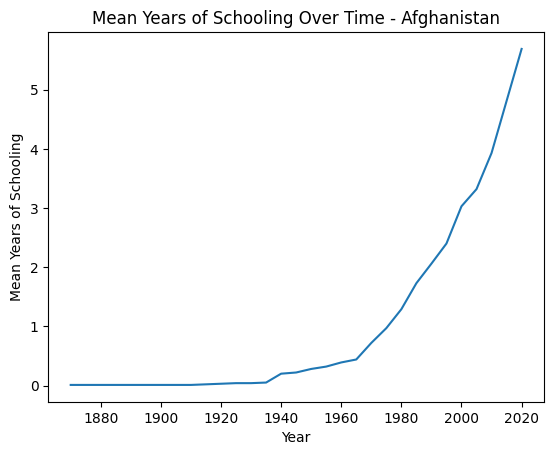

In [20]:
import matplotlib.pyplot as plt

plt.plot(country_trend['year'], country_trend['mean_years_schooling'])
plt.title(f"Mean Years of Schooling Over Time - {country_name}")
plt.xlabel("Year")
plt.ylabel("Mean Years of Schooling")
plt.show()